# Inference of spatially resolved tau amplification rates on synthetic brain images

This notebook builds a lightweight synthetic neuroimaging example for differentiable tau propagation. It follows the forward reaction–diffusion simulation pattern used in `examples/forward_simulation.ipynb`, but replaces real neuroimaging inputs such as MRI, DTI, and atlas files with synthetic brain masks and diffusion fields.

After the forward simulation setup, the notebook constructs a synthetic ground-truth amplification-rate field, `alpha`, generates a target tau/prion propagation pattern, and demonstrates gradient-based recovery of `alpha` by backpropagating errors through the differentiable reaction–diffusion simulator.

## Setup

Keep the example CPU-friendly by using a small grid and short simulation horizon. The notebook reuses preprocessing and simulation functions from `simndd` whenever possible.

In [1]:
import os
import time

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

import jax
import jax.numpy as jnp

from simndd.input_generator import (
    convert_diffusion_tensor_field,
    smooth_initial_field,
    smooth_phase_boundary,
)
from simndd.simulator import simulate_scan, update_fisher_from_seed
from simndd.visualizer import plot_phase_field, plot_simulation, volume_slicer

print("jax version:", jax.__version__)
print("jax backend:", jax.default_backend())

grid_shape = (32, 32, 32)
slice_idx = grid_shape[1] // 2
dt = 0.001
dx = 1.0
n_time = 5
n_step = 200
alpha_low = 0.25
alpha_high = 0.5
sigma_alpha = 6.0

plt.rcParams.update({"figure.dpi": 120, "axes.spines.right": False, "axes.spines.top": False})

jax version: 0.4.26
jax backend: cpu


## Synthetic Brain, Gray Matter, and White Matter Masks

Represent the brain as a sphere inside a `32 x 32 x 32` voxel volume. Gray matter is approximated as a thin shell near the surface, and white matter is the inner sphere.

In [2]:
def spherical_mask(shape, center, radius):
    coords = np.indices(shape, dtype=np.float32)
    dist2 = sum((coords[axis] - center[axis]) ** 2 for axis in range(3))
    return dist2 <= radius**2


center = np.array([(n - 1) / 2 for n in grid_shape], dtype=np.float32)
brain_radius = 13.5
gray_shell_thickness = 3.0

coords = np.indices(grid_shape, dtype=np.float32)
distance_from_center = np.sqrt(sum((coords[axis] - center[axis]) ** 2 for axis in range(3)))

brain_mask = distance_from_center <= brain_radius
white_mask = distance_from_center <= (brain_radius - gray_shell_thickness)
gray_mask = brain_mask & ~white_mask

print("brain voxels:", int(brain_mask.sum()))
print("gray matter voxels:", int(gray_mask.sum()))
print("white matter voxels:", int(white_mask.sum()))

brain voxels: 10144
gray matter voxels: 5368
white matter voxels: 4776


Visualize the central coronal slice of the three masks. These arrays replace the real brain and tissue masks loaded in `examples/forward_simulation.ipynb`.

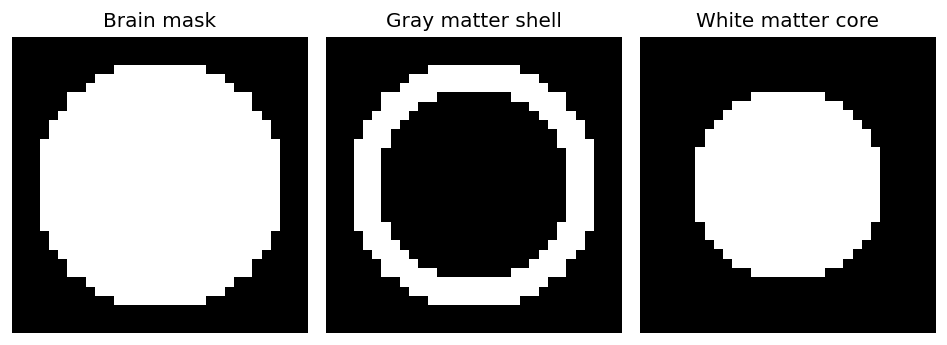

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, vol, title in zip(
    axes,
    [brain_mask, gray_mask, white_mask],
    ["Brain mask", "Gray matter shell", "White matter core"],
):
    ax.imshow(volume_slicer(vol, "coronal", slice_idx), cmap="gray", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

## Synthetic DTI-Like Field

Create an idealized tensor field whose raw DTI signal is nonzero only in white matter. The principal direction is uniformly aligned with the z-axis, so the largest eigenvalue is `D_zz`.

In [4]:
synthetic_dti = np.zeros((*grid_shape, 9), dtype=np.float32)
raw_tensor = np.diag([0.2, 0.2, 1.0]).astype(np.float32).ravel()
synthetic_dti[white_mask] = raw_tensor

principal_direction = np.zeros((*grid_shape, 3), dtype=np.float32)
principal_direction[white_mask, 2] = 1.0

print("synthetic_dti.shape:", synthetic_dti.shape)
print("nonzero raw DTI voxels:", int(np.any(synthetic_dti != 0, axis=-1).sum()))

synthetic_dti.shape: (32, 32, 32, 9)
nonzero raw DTI voxels: 4776


Plot the raw `D_zz` component and the principal fiber direction on the central coronal slice. In this slice, the z-direction appears as horizontal arrows.

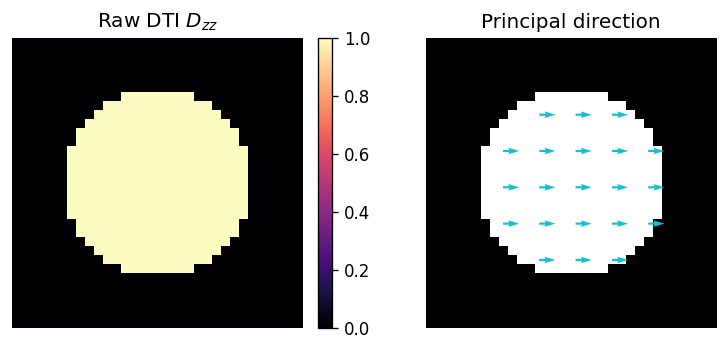

In [5]:
dzz_slice = volume_slicer(synthetic_dti[..., 8], "coronal", slice_idx)
wm_slice = volume_slicer(white_mask, "coronal", slice_idx)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
im = axes[0].imshow(dzz_slice, cmap="magma", interpolation="nearest")
axes[0].set_title("Raw DTI $D_{zz}$")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(wm_slice, cmap="gray", interpolation="nearest")
step = 4
rows, cols = np.mgrid[0:grid_shape[0]:step, 0:grid_shape[2]:step]
inside = wm_slice[rows, cols]
axes[1].quiver(cols[inside], rows[inside], np.ones_like(cols[inside]), np.zeros_like(rows[inside]), color="tab:cyan", scale=18)
axes[1].set_title("Principal direction")
axes[1].axis("off")
plt.tight_layout()

## Phase Field and Processed Diffusion Tensor

Follow the forward example preprocessing: smooth the binary brain mask into a phase field and convert the DTI-like tensor field into the diffusion tensor used by the simulator. The conversion function adds gray-matter-like isotropic diffusion in gray matter and virtual boundary voxels for numerical stability.

mode:  anisotropic
phase.shape: (32, 32, 32) phase dtype: float32
processed_dti.shape: (32, 32, 32, 9) processed_dti dtype: float32
min positive phase: 0.00022727738542016596


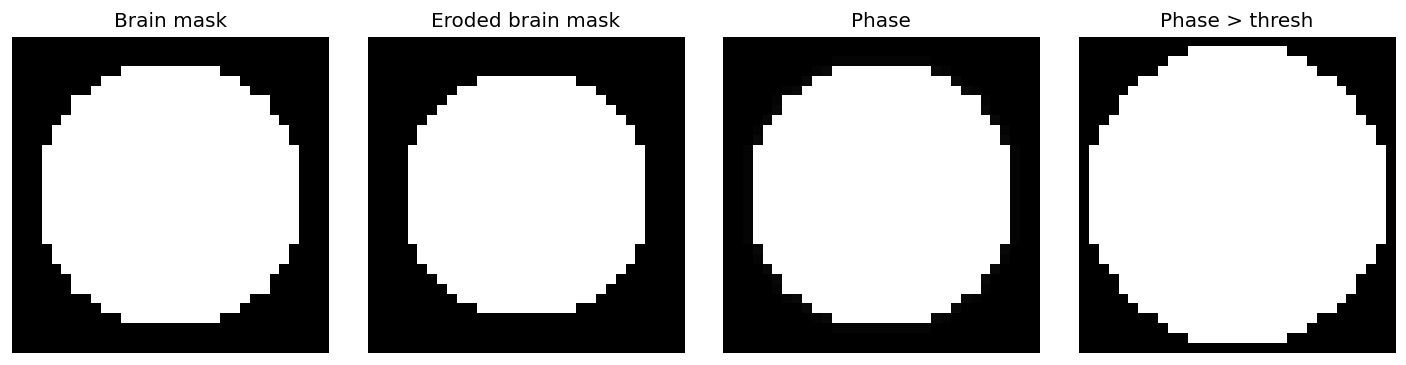

In [6]:
brain_mask_float = brain_mask.astype(np.float32)
gray_mask_float = gray_mask.astype(np.float32)

phase = smooth_phase_boundary(brain_mask_float)
processed_dti = convert_diffusion_tensor_field(synthetic_dti, brain_mask_float, gray_mask_float, mode="anisotropic")

print("phase.shape:", phase.shape, "phase dtype:", phase.dtype)
print("processed_dti.shape:", processed_dti.shape, "processed_dti dtype:", processed_dti.dtype)
print("min positive phase:", float(phase[phase > 0].min()))

plot_phase_field(brain_mask, phase, "coronal", slice_idx)

Inspect the processed diffusion tensor components. The white matter core has strong `D_zz`, while gray matter and boundary voxels use isotropic diffusion from `convert_diffusion_tensor_field`.

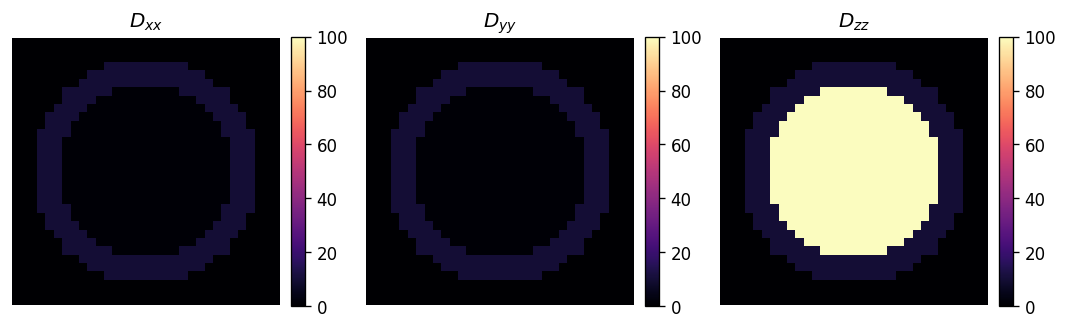

In [7]:
components = [(0, "$D_{xx}$"), (4, "$D_{yy}$"), (8, "$D_{zz}$")]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, (component, title) in zip(axes, components):
    im = ax.imshow(
        volume_slicer(processed_dti[..., component] * brain_mask, "coronal", slice_idx),
        cmap="magma",
        interpolation="nearest",
        vmin=0,
        vmax=100,
    )
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

## Initial Seed

Use a small spherical seed in white matter. As in the forward example, smooth the seed before simulation to reduce numerical artifacts, while `update_fisher_from_seed` keeps the binary seed clamped during time stepping.

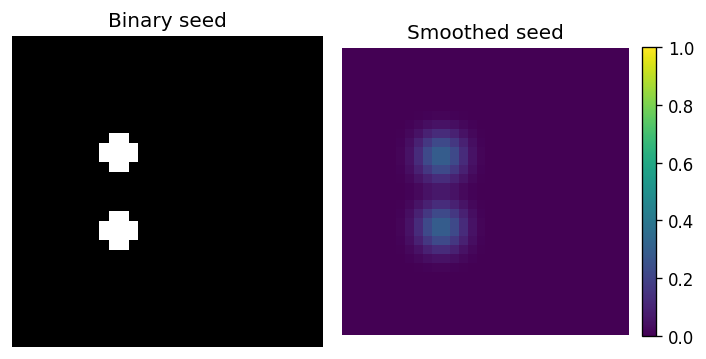

In [8]:
seed_center = center + np.array([4.0, 0.0, -5.0], dtype=np.float32)
seed_mask = spherical_mask(grid_shape, seed_center, radius=2.0) & brain_mask
seed_center = center + np.array([-4.0, 0.0, -5.0], dtype=np.float32)
seed_mask += spherical_mask(grid_shape, seed_center, radius=2.0) & brain_mask
prion_init = smooth_initial_field(seed_mask, sigma=1.6)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(volume_slicer(seed_mask, "coronal", slice_idx), cmap="gray", interpolation="nearest")
axes[0].set_title("Binary seed")
axes[0].axis("off")
im = axes[1].imshow(volume_slicer(prion_init * brain_mask, "coronal", slice_idx), cmap="viridis", interpolation="nearest", vmin=0, vmax=1)
axes[1].set_title("Smoothed seed")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()

## Synthetic map of tau amplification rates

alpha_map min/max in brain: 2.081766128540039 10.0


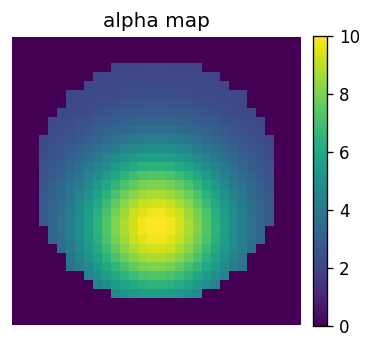

In [9]:
alpha_low = 2.0
alpha_high = 10.0
sigma_alpha = 6.0
alpha_center = center + np.array([5.0, 0.0, 0.0], dtype=np.float32)
coords = np.indices(grid_shape, dtype=np.float32)
distance2 = (
    (coords[0] - alpha_center[0]) ** 2
    + (coords[1] - alpha_center[1]) ** 2
    + (coords[2] - alpha_center[2]) ** 2
)

gaussian = np.exp(-distance2 / (2.0 * sigma_alpha**2)).astype(np.float32)
gaussian /= np.maximum(float(gaussian.max()), 1e-8)

alpha_map = alpha_low + (alpha_high - alpha_low) * gaussian
alpha_map = np.where(brain_mask, alpha_map, 0.0).astype(np.float32)

print("alpha_map min/max in brain:", float(alpha_map[brain_mask].min()), float(alpha_map[brain_mask].max()))

fig, ax = plt.subplots(figsize=(3.2, 3.2))
im = ax.imshow(volume_slicer(alpha_map, "coronal", slice_idx), cmap="viridis", interpolation="nearest")
ax.set_title("alpha map")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

## Forward Reaction-Diffusion Simulation

Run the same simulation pattern as the real-data notebook: `simulate_scan` advances the field with `update_fisher_from_seed`, using the phase field, processed diffusion tensor, fixed seed mask, and uniform amplification rate.

In [10]:
t_start = time.time()
dti_scale = 0.1
history = simulate_scan(
    prion_init,
    phase.copy(),
    args=[seed_mask, dti_scale * processed_dti, alpha_map],
    dt=dt,
    dx=dx,
    n_time=n_time,
    n_step=n_step,
    update_func=update_fisher_from_seed,
)
history = np.stack(history)

print(f"simulation wall time: {time.time() - t_start:.2f} sec")
print("history.shape:", history.shape)
print("final max tau:", float(history[-1].max()))

0  th step...
200  th step...
400  th step...
600  th step...
800  th step...
simulation wall time: 1.36 sec
history.shape: (6, 32, 32, 32)
final max tau: 1.0


## Simulation Result

Visualize the simulated tau/prion field over time and inspect the final field. Multiplying by the phase field hides values outside the synthetic brain.

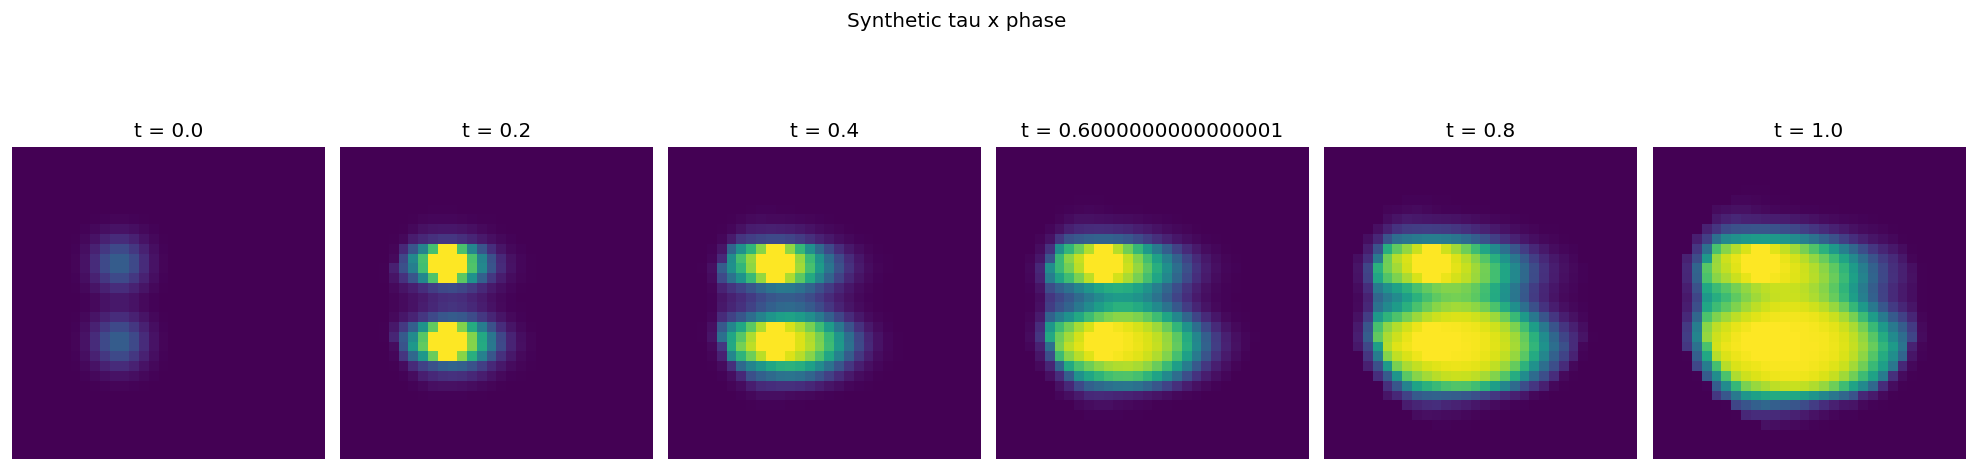

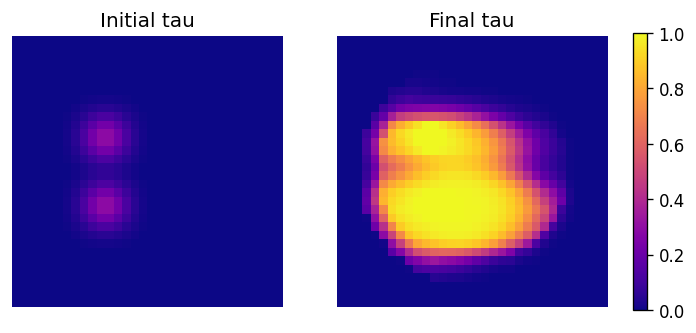

In [11]:
plot_simulation(
    history,
    t_intv=n_step * dt,
    plane="coronal",
    idx=slice_idx,
    mask=phase,
    fig_suptitle="Synthetic tau x phase",
)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
im0 = axes[0].imshow(volume_slicer(history[0] * phase, "coronal", slice_idx), cmap="plasma", interpolation="nearest", vmin=0, vmax=1)
axes[0].set_title("Initial tau")
axes[0].axis("off")
im1 = axes[1].imshow(volume_slicer(history[-1] * phase, "coronal", slice_idx), cmap="plasma", interpolation="nearest", vmin=0, vmax=1)
axes[1].set_title("Final tau")
axes[1].axis("off")
plt.colorbar(im1, ax=axes, fraction=0.046, pad=0.04)
#plt.tight_layout()

# Library imports for differentiable optimization
We use the `scan` function from `equinox.internal`, which supports checkpointing to reduce memory usage during backpropagation through time.

In [12]:
import importlib
import equinox.internal as eqxi
import simndd.learner as learner

# Ensure the currently loaded module reflects the latest file on disk.
#learner = importlib.reload(learner)

from simndd.learner import (
    eqxi_scan_update_func,
    squared_voxelwise_error_on_phase,
    root_sum_of_squared_voxelwise_error_on_phase,
)

# Synthetic alpha recovery by error backpropagation

In [13]:
synthetic_pet = jnp.asarray(history[-1] * phase, dtype=jnp.float32)
phi_jax = jnp.asarray(phase, dtype=jnp.float32)
prion0_jax = jnp.asarray(prion_init, dtype=jnp.float32)
seed_mask_jax = jnp.asarray(seed_mask)
dti_jax = jnp.asarray(dti_scale * processed_dti, dtype=jnp.float32)
alpha_target = jnp.asarray(alpha_map, dtype=jnp.float32)

alpha_current = jnp.ones_like(alpha_target) * (alpha_low + alpha_high) / 2
n_step_total = n_time * n_step
n_epoch = 50
learning_rate = 1.0
grad_scale = 30.0

def loss_fn(alpha):
    return root_sum_of_squared_voxelwise_error_on_phase(
        prion0_jax,
        synthetic_pet,
        phi_jax,
        alpha,
        [seed_mask_jax, dti_jax],
        dt,
        dx,
        n_step_total,
        update_fisher_from_seed,
    )

loss_and_grad_fn = jax.jit(jax.value_and_grad(loss_fn))

loss_history = []
grad_norm_history = []
grad_absmax_history = []

for epoch in range(n_epoch):
    loss_value, grad_alpha = loss_and_grad_fn(alpha_current)

    grad_norm = jnp.linalg.norm(grad_alpha)
    grad_absmax = jnp.max(jnp.abs(grad_alpha))

    alpha_current = alpha_current - learning_rate * grad_scale * grad_alpha
    alpha_current = jnp.where(phi_jax > 0, alpha_current, 0.0)
    alpha_current = jnp.clip(alpha_current, 0.0, alpha_high * 1.5)

    loss_history.append(float(loss_value))
    grad_norm_history.append(float(grad_norm))
    grad_absmax_history.append(float(grad_absmax))

    if epoch % 2 == 0 or epoch == n_epoch - 1:
        print(
            f"epoch {epoch:03d} | loss = {float(loss_value):.6e} | ",
            f"||grad||_2 = {float(grad_norm):.6e} | ",
            f"max|grad| = {float(grad_absmax):.6e}"
        )

print("optimization done")
print(
    "alpha_current min/max in brain:",
    float(alpha_current[phi_jax > 0].min()),
    float(alpha_current[phi_jax > 0].max()),
)

epoch 000 | loss = 1.811628e+01 |  ||grad||_2 = 1.710760e-01 |  max|grad| = 9.635579e-03
epoch 002 | loss = 1.632682e+01 |  ||grad||_2 = 1.748643e-01 |  max|grad| = 9.914896e-03
epoch 004 | loss = 1.448316e+01 |  ||grad||_2 = 1.754027e-01 |  max|grad| = 9.564662e-03
epoch 006 | loss = 1.265438e+01 |  ||grad||_2 = 1.726479e-01 |  max|grad| = 9.824471e-03
epoch 008 | loss = 1.090802e+01 |  ||grad||_2 = 1.666162e-01 |  max|grad| = 9.513957e-03
epoch 010 | loss = 9.303939e+00 |  ||grad||_2 = 1.580153e-01 |  max|grad| = 8.264786e-03
epoch 012 | loss = 7.873044e+00 |  ||grad||_2 = 1.483449e-01 |  max|grad| = 8.261236e-03
epoch 014 | loss = 6.619543e+00 |  ||grad||_2 = 1.380877e-01 |  max|grad| = 7.063894e-03
epoch 016 | loss = 5.540708e+00 |  ||grad||_2 = 1.273345e-01 |  max|grad| = 6.672557e-03
epoch 018 | loss = 4.630580e+00 |  ||grad||_2 = 1.160535e-01 |  max|grad| = 6.012961e-03
epoch 020 | loss = 3.882744e+00 |  ||grad||_2 = 1.041211e-01 |  max|grad| = 5.659128e-03
epoch 022 | loss = 3.

# Comparison between target and simulated tau patterns
Simulated tau pattern generated using optimized `alpha` map.

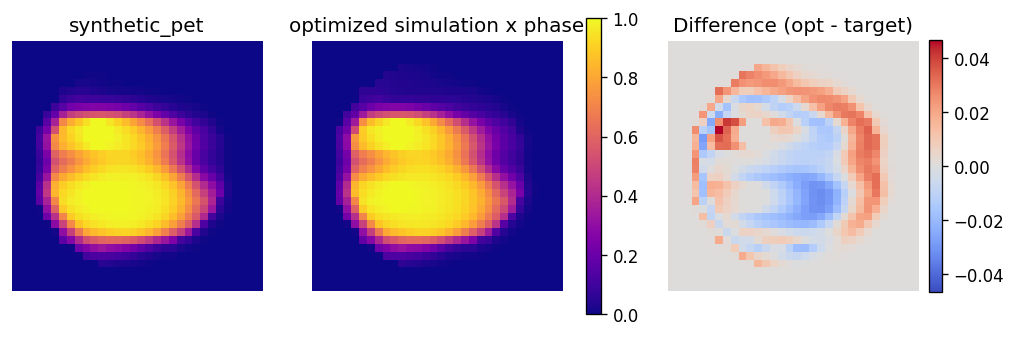

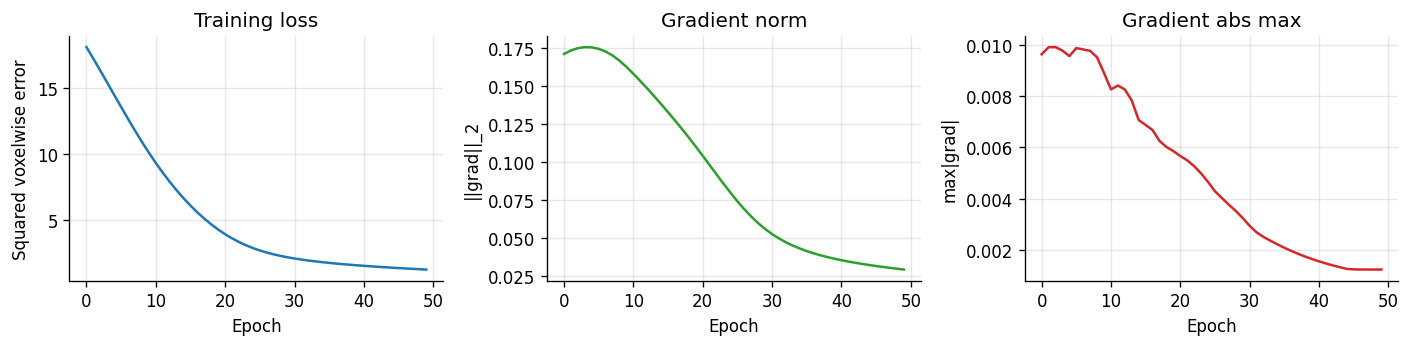

In [14]:
# Re-simulate with optimized alpha and compare in phase space.
sim_opt = eqxi_scan_update_func(
    prion0_jax,
    phi_jax,
    [seed_mask_jax, dti_jax, alpha_current],
    dt,
    dx,
    n_step_total,
    update_fisher_from_seed,
)
sim_opt_phase = sim_opt * phi_jax

synthetic_pet_np = np.asarray(synthetic_pet)
sim_opt_phase_np = np.asarray(sim_opt_phase)
alpha_map_np = np.asarray(alpha_map)
alpha_current_np = np.asarray(alpha_current)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
pet_slice = volume_slicer(synthetic_pet_np, "coronal", slice_idx)
opt_slice = volume_slicer(sim_opt_phase_np, "coronal", slice_idx)
diff_slice = opt_slice - pet_slice

vmin_pet = float(min(synthetic_pet_np.min(), sim_opt_phase_np.min()))
vmax_pet = float(max(synthetic_pet_np.max(), sim_opt_phase_np.max()))

im0 = axes[0].imshow(pet_slice, cmap="plasma", interpolation="nearest", vmin=vmin_pet, vmax=vmax_pet)
axes[0].set_title("synthetic_pet")
axes[0].axis("off")

im1 = axes[1].imshow(opt_slice, cmap="plasma", interpolation="nearest", vmin=vmin_pet, vmax=vmax_pet)
axes[1].set_title("optimized simulation x phase")
axes[1].axis("off")

diff_vmax = max(abs(diff_slice.min()), abs(diff_slice.max()))
im2 = axes[2].imshow(diff_slice, cmap="coolwarm", interpolation="nearest", vmin=-diff_vmax, vmax=diff_vmax)
axes[2].set_title("Difference (opt - target)")
axes[2].axis("off")

plt.colorbar(im0, ax=axes[:2], fraction=0.046, pad=0.04)
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(loss_history, color="tab:blue")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Squared voxelwise error")
axes[0].grid(alpha=0.3)

axes[1].plot(grad_norm_history, color="tab:green")
axes[1].set_title("Gradient norm")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("||grad||_2")
axes[1].grid(alpha=0.3)

axes[2].plot(grad_absmax_history, color="tab:red")
axes[2].set_title("Gradient abs max")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("max|grad|")
axes[2].grid(alpha=0.3)
plt.tight_layout()

# Comparison between ground-truth and inferred alpha maps
Although this validation is performed on a simple synthetic-brain geometry, the comparison highlights two sources of mismatch between the recovered and ground-truth amplification-rate maps.
First, in regions that have not been reached by tau propagation, tau amplification does not effectively occur. In these regions, changes in `alpha` have little or no effect on the simulated outcome, and therefore error backpropagation does not produce meaningful updates of `alpha`. Second, a similar loss of sensitivity occurs around the seed region, where the tau field rapidly becomes saturated. Then local changes in `alpha` around the seed region no longer strongly affect the final output.

Therefore, high or low values of the recovered `alpha` tend to indicate high or low values of the ground-truth `alpha`, but the converse does not necessarily hold: regions with high or low ground-truth `alpha` may not be recovered if they are outside the propagation-sensitive regime. Consistent with this interpretation, excluding voxels with particularly high or low tau values substantially improves the Pearson correlation between the ground-truth and recovered `alpha` maps, from 0.5 to 0.9.

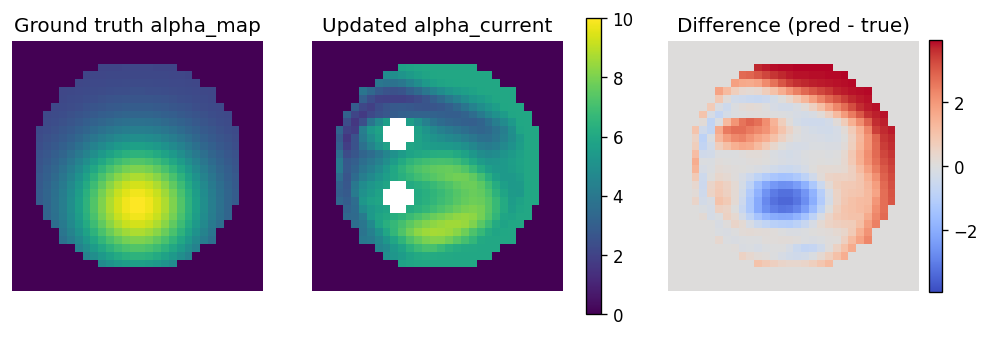

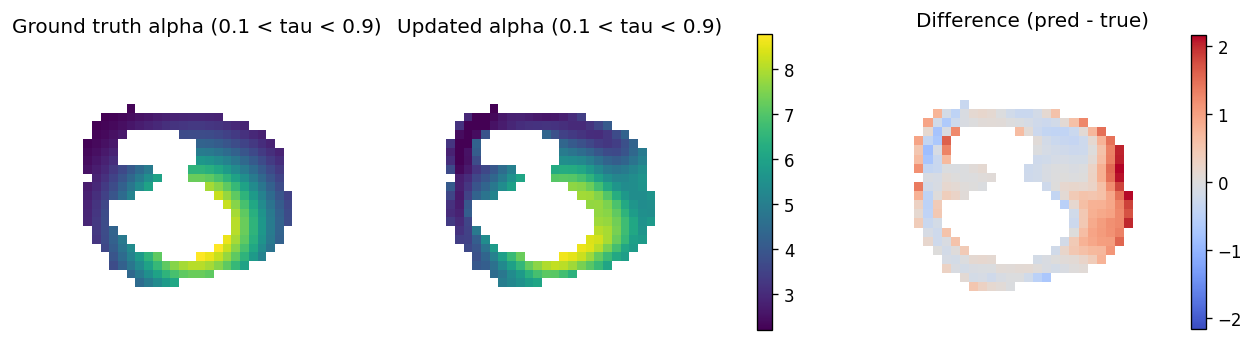

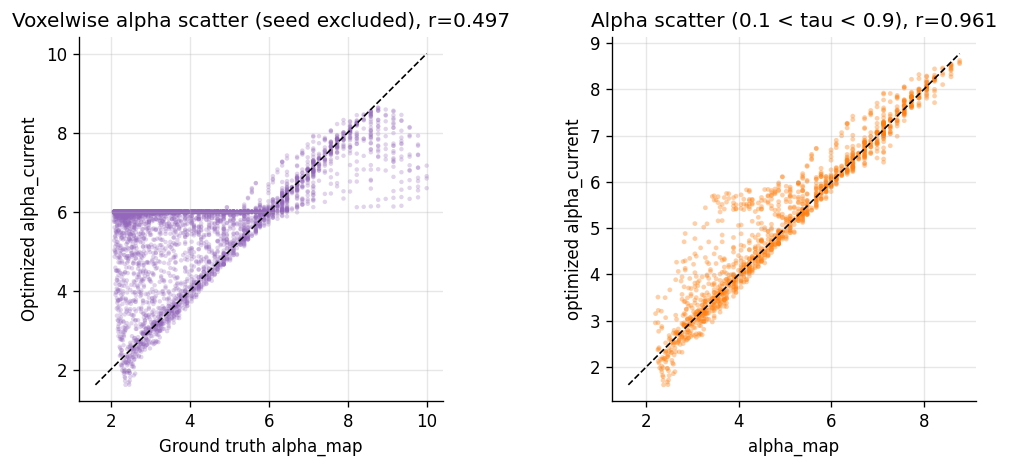

In [15]:
#
# Visualize the ground truth and updated alpha maps, and their difference, at all voxels.
#
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
gt_slice = volume_slicer(np.asarray(alpha_map) * brain_mask, "coronal", slice_idx)
pred_slice = volume_slicer(np.asarray(alpha_current) * brain_mask, "coronal", slice_idx)
seed_slice = volume_slicer(seed_mask, "coronal", slice_idx).astype(bool)
err_slice = pred_slice - gt_slice

vmin = float(np.min(gt_slice))
vmax = float(np.max(gt_slice))

im0 = axes[0].imshow(gt_slice, cmap="viridis", interpolation="nearest", vmin=vmin, vmax=vmax)
axes[0].set_title("Ground truth alpha_map")
axes[0].axis("off")

pred_slice_masked = np.ma.masked_where(seed_slice, pred_slice)
diff_vmax = float(np.max(np.abs(err_slice)))
im1 = axes[1].imshow(pred_slice_masked, cmap="viridis", interpolation="nearest", vmin=vmin, vmax=vmax)
axes[1].set_title("Updated alpha_current")
axes[1].axis("off")

im2 = axes[2].imshow(err_slice, cmap="coolwarm", interpolation="nearest", vmin=-diff_vmax, vmax=diff_vmax)
axes[2].set_title("Difference (pred - true)")
axes[2].axis("off")
plt.colorbar(im0, ax=axes[:2], fraction=0.046, pad=0.04)
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

#
# Visualize the ground truth and updated alpha maps at voxels with 0.1 < tau < 0.9n.
#
alpha_map_np = np.asarray(alpha_map)
alpha_current_np = np.asarray(alpha_current)
seed_mask_np = np.asarray(seed_mask, dtype=bool)

brain_no_seed_mask = brain_mask & (~seed_mask_np)

alpha_true = alpha_map_np[brain_no_seed_mask]
alpha_pred = alpha_current_np[brain_no_seed_mask]

mask_tau_mid = (sim_opt_phase_np > 0.1) & (sim_opt_phase_np < 0.9) & brain_mask
x2 = alpha_map_np[mask_tau_mid]
y2 = alpha_current_np[mask_tau_mid]

# Pearson correlation for both scatter datasets.
r_all = float(np.corrcoef(alpha_true, alpha_pred)[0, 1])
r_mid = float(np.corrcoef(x2, y2)[0, 1])

fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.2))
alpha_gt_mid = np.ma.masked_where(~mask_tau_mid, alpha_map_np)
alpha_pred_mid = np.ma.masked_where(~mask_tau_mid, alpha_current_np)
alpha_diff_mid = alpha_pred_mid - alpha_gt_mid

gt_mid_slice = volume_slicer(alpha_gt_mid, "coronal", slice_idx)
pred_mid_slice = volume_slicer(alpha_pred_mid, "coronal", slice_idx)
diff_mid_slice = volume_slicer(alpha_diff_mid, "coronal", slice_idx)

vmin_mid = float(np.min(x2))
vmax_mid = float(np.max(x2))
diff_mid_vmax = float(np.max(np.abs(diff_mid_slice)))

im0 = axes[0].imshow(gt_mid_slice, cmap="viridis", interpolation="nearest", vmin=vmin_mid, vmax=vmax_mid)
axes[0].set_title("Ground truth alpha (0.1 < tau < 0.9)")
axes[0].axis("off")

im1 = axes[1].imshow(pred_mid_slice, cmap="viridis", interpolation="nearest", vmin=vmin_mid, vmax=vmax_mid)
axes[1].set_title("Updated alpha (0.1 < tau < 0.9)")
axes[1].axis("off")

im2 = axes[2].imshow(diff_mid_slice, cmap="coolwarm", interpolation="nearest", vmin=-diff_mid_vmax, vmax=diff_mid_vmax)
axes[2].set_title("Difference (pred - true)")
axes[2].axis("off")

fig.subplots_adjust(wspace=0.30, right=0.95)
plt.colorbar(im0, ax=axes[:2], fraction=0.046, pad=0.08)
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

#
# Scatter plot of alpha values at all brain voxels (excluding seed) and at voxels with 0.1 < tau < 0.9.
#
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0))

axes[0].scatter(alpha_true, alpha_pred, s=7, alpha=0.15, color="tab:purple", edgecolors="none")
line_min = float(min(alpha_true.min(), alpha_pred.min()))
line_max = float(max(alpha_true.max(), alpha_pred.max()))
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black", linewidth=1.0)
axes[0].set_title(f"Voxelwise alpha scatter (seed excluded), r={r_all:.3f}")
axes[0].set_xlabel("Ground truth alpha_map")
axes[0].set_ylabel("Optimized alpha_current")
axes[0].grid(alpha=0.3)
axes[0].set_aspect("equal", adjustable="box")

axes[1].scatter(x2, y2, s=8, alpha=0.2, color="tab:orange", edgecolors="none")
line_min2 = float(min(x2.min(), y2.min()))
line_max2 = float(max(x2.max(), y2.max()))
axes[1].plot([line_min2, line_max2], [line_min2, line_max2], "k--", linewidth=1.0)
axes[1].set_title(f"Alpha scatter (0.1 < tau < 0.9), r={r_mid:.3f}")
axes[1].set_xlabel("alpha_map")
axes[1].set_ylabel("optimized alpha_current")
axes[1].grid(alpha=0.3)
axes[1].set_aspect("equal", adjustable="box")
plt.tight_layout()

In [16]:
#
# Sanity check: compute the loss with the ground-truth alpha_map to confirm it is close to zero (within numerical precision limits).
#
alpha_gt_jax = jnp.asarray(alpha_map, dtype=jnp.float32)

sq_err_gt = squared_voxelwise_error_on_phase(
    prion0_jax,
    synthetic_pet,
    phi_jax,
    alpha_gt_jax,
    [seed_mask_jax, dti_jax],
    dt,
    dx,
    n_step_total,
    update_fisher_from_seed,
)

sq_err_gt_float = float(sq_err_gt)
print("phase-space squared_voxelwise_error (ground-truth alpha):", sq_err_gt_float)
print("exactly zero?", sq_err_gt_float == 0.0)
print("isclose to zero (atol=1e-8)?", bool(np.isclose(sq_err_gt_float, 0.0, atol=1e-8)))
print("isclose to zero (atol=1e-5)?", bool(np.isclose(sq_err_gt_float, 0.0, atol=1e-5)))

phase-space squared_voxelwise_error (ground-truth alpha): 0.0
exactly zero? True
isclose to zero (atol=1e-8)? True
isclose to zero (atol=1e-5)? True
